In [18]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

In [19]:

# 0. QUANTUM RANDOM NUMBER GENERATOR
# Place Qubits into quantum superpositions and measure them to get a random set of Qubits

def qrng(num_bits):
    qc = QuantumCircuit(num_bits, num_bits)
    qc.h(range(num_bits)) # Put all qubits into |+> state
    qc.measure(range(num_bits), range(num_bits))

    backend = BasicSimulator()
    compiled = transpile(qc, backend)
    job = backend.run(compiled, shots=1)

    # Little-Endian to Big-Endian (reverse)
    result_str = list(job.result().get_counts().keys())[0][::-1]
    return [int(bit) for bit in result_str]


<IPython.core.display.Javascript object>


                  --- RUNNING PURE BB84 PROTOCOL (No Attacker) ---                   

+---------------------------------------------------------------+
|                        PROTOCOL LEGEND                        |
+---------------------------------------------------------------+
| S : Standard / Z-basis  (Encodes/Measures purely |0> and |1>) |
| D : Diagonal / X-basis  (Encodes/Measures purely |+> and |->) |
+---------------------------------------------------------------+

--- PHASE 0: ALICE'S PREPARATION ---
-------------------------------------------------------------
|  Qubit  |  Alice Bit  |  Chosen Basis  |  Prepared State  |
-------------------------------------------------------------
|    0    |      0      |       D        |       |+>        |
|    1    |      1      |       S        |       |1>        |
|    2    |      1      |       S        |       |1>        |
|    3    |      0      |       D        |       |+>        |
|    4    |      1      |       S        |  

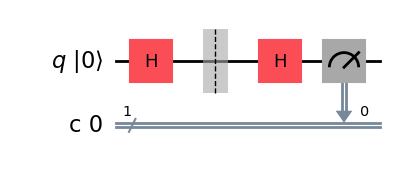


[Qubit 1]
  Alice sends Bit: 1  |  Encodes in: Standard (S)
  Bob measures in: Standard (S)
  Bob's result:    1


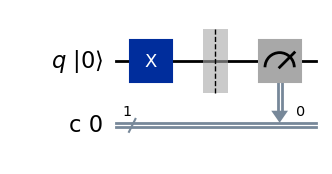


[Qubit 2]
  Alice sends Bit: 1  |  Encodes in: Standard (S)
  Bob measures in: Diagonal (D)
  Bob's result:    0


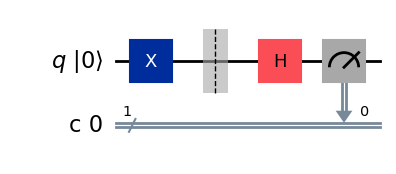


[Qubit 3]
  Alice sends Bit: 0  |  Encodes in: Diagonal (D)
  Bob measures in: Diagonal (D)
  Bob's result:    0


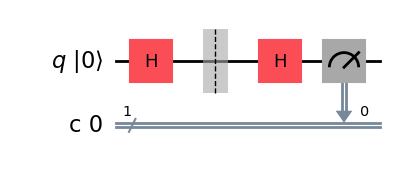


[Qubit 4]
  Alice sends Bit: 1  |  Encodes in: Standard (S)
  Bob measures in: Diagonal (D)
  Bob's result:    0


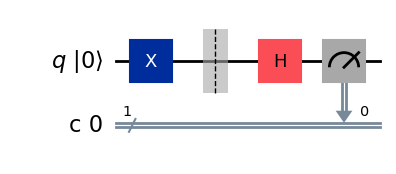


[Qubit 5]
  Alice sends Bit: 1  |  Encodes in: Diagonal (D)
  Bob measures in: Standard (S)
  Bob's result:    1


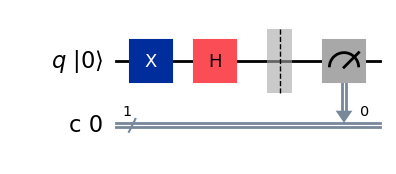


[Qubit 6]
  Alice sends Bit: 1  |  Encodes in: Standard (S)
  Bob measures in: Standard (S)
  Bob's result:    1


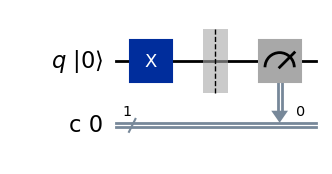


[Qubit 7]
  Alice sends Bit: 0  |  Encodes in: Standard (S)
  Bob measures in: Standard (S)
  Bob's result:    0


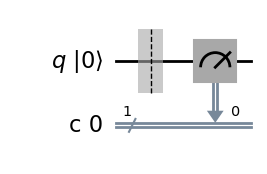


[Qubit 8]
  Alice sends Bit: 1  |  Encodes in: Diagonal (D)
  Bob measures in: Diagonal (D)
  Bob's result:    1


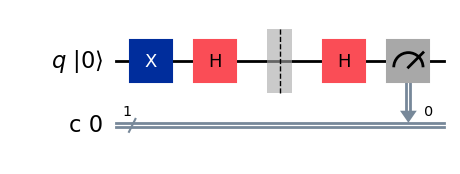


[Qubit 9]
  Alice sends Bit: 0  |  Encodes in: Diagonal (D)
  Bob measures in: Standard (S)
  Bob's result:    0


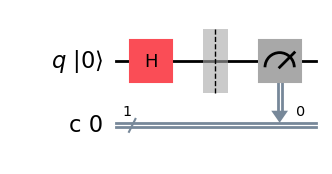


--- PHASE 2 & 3: SIFTING & ERROR CHECKING ---
  Total Qubits:       10
  Sifted Key Length:  6
  Errors Detected:    0
  Error Rate:         0.00%

  >> SUCCESS: Channel is secure. Keys match perfectly.

                    --- PHASE 4: COMPLETE TRANSMISSION RECORD ---                    
  [THE 'MATCH?' COLUMN]
  This column ONLY checks if Alice and Bob randomly chose the EXACT SAME BASIS (S or D).
  - YES: The physics align. Bob's reading is mathematically guaranteed to be correct.
  - NO:  The physics mismatch. Bob's reading is a random coin flip (garbage data).
---------------------------------------------------------------------------------------------
|  Qubit  |  Alice Bit  |  Alice Basis  |  Sent State  |  Bob Basis  |  Bob Bit  |  Match?  |
---------------------------------------------------------------------------------------------
|    0    |      0      |       D       |     |+>      |      D      |     0     |   YES    |
|    1    |      1      |       S       |     |1>  

In [22]:

from google.colab import output
output.no_vertical_scroll()


# THE PURE BB84 PROTOCOL (ALICE & BOB)

def run_bb84(num_qubits=5):
    print(f"\n{'='*85}")
    print(f"{'--- RUNNING PURE BB84 PROTOCOL (No Attacker) ---':^85}")
    print(f"{'='*85}")

    basis_name = {0: "Standard (S)", 1: "Diagonal (D)"}
    short_basis = {0: "S", 1: "D"}


    # DYNAMIC LEGEND GENERATOR
    leg_title = "PROTOCOL LEGEND"
    leg_1 = "S : Standard / Z-basis  (Encodes/Measures purely |0> and |1>)"
    leg_2 = "D : Diagonal / X-basis  (Encodes/Measures purely |+> and |->)"
    max_len = max(len(leg_title), len(leg_1), len(leg_2)) + 2
    leg_border = "+" + "-" * max_len + "+"
    print("\n" + leg_border)
    print(f"|{leg_title:^{max_len}}|")
    print(leg_border)
    print(f"| {leg_1:<{max_len-1}}|")
    print(f"| {leg_2:<{max_len-1}}|")
    print(leg_border + "\n")

    # Gen randoms
    alice_bits = qrng(num_qubits)
    alice_bases = qrng(num_qubits)
    bob_bases = qrng(num_qubits)

    bob_results = []
    alice_states = []

    backend = BasicSimulator()


    # PHASE 0: PREPARATION (Print Alices bits, basis and states)

    print("--- PHASE 0: ALICE'S PREPARATION ---")
    a_bases_str = [short_basis[b] for b in alice_bases]
    for i in range(num_qubits):
        if alice_bases[i] == 0:
            state = "|1>" if alice_bits[i] == 1 else "|0>"
        else:
            state = "|->" if alice_bits[i] == 1 else "|+>"
        alice_states.append(state)
    p0_headers = ["Qubit", "Alice Bit", "Chosen Basis", "Prepared State"]
    p0_widths = [len(h) + 2 for h in p0_headers]
    p0_head_str = "| " + " | ".join([f"{h:^{w}}" for h, w in zip(p0_headers, p0_widths)]) + " |"
    p0_border = "-" * len(p0_head_str)
    print(p0_border)
    print(p0_head_str)
    print(p0_border)
    for i in range(num_qubits):
        print(f"| {i:^{p0_widths[0]}} | {alice_bits[i]:^{p0_widths[1]}} | {a_bases_str[i]:^{p0_widths[2]}} | {alice_states[i]:^{p0_widths[3]}} |")
    print(p0_border + "\n")


    # PHASE 1: TRANSMISSION

    print("--- PHASE 1: TRANSMISSION & MEASUREMENT ---")
    for i in range(num_qubits):
        print(f"\n[Qubit {i}]")
        qc = QuantumCircuit(1, 1)

        # --- ALICE ---
        print(f"  Alice sends Bit: {alice_bits[i]}  |  Encodes in: {basis_name[alice_bases[i]]}")
        if alice_bits[i] == 1:
            qc.x(0)
        if alice_bases[i] == 1:
            qc.h(0)

        # THE BARRIER: Separating Alice and Bob!
        qc.barrier()

        # --- BOB ---
        print(f"  Bob measures in: {basis_name[bob_bases[i]]}")
        if bob_bases[i] == 1:
            qc.h(0)

        qc.measure(0, 0)

        compiled = transpile(qc, backend)
        job = backend.run(compiled, shots=1)
        bob_bit = int(list(job.result().get_counts().keys())[0])
        bob_results.append(bob_bit)

        print(f"  Bob's result:    {bob_bit}")
        display(qc.draw("mpl", initial_state=True))


    # PHASE 2 & 3: SIFTING & CHECKING

    print("\n" + "="*85)
    print("--- PHASE 2 & 3: SIFTING & ERROR CHECKING ---")

    alice_sifted_key = []
    bob_sifted_key = []

    for i in range(num_qubits):
        if alice_bases[i] == bob_bases[i]:
            alice_sifted_key.append(alice_bits[i])
            bob_sifted_key.append(bob_results[i])

    errors = sum(1 for a, b in zip(alice_sifted_key, bob_sifted_key) if a != b)
    error_rate = errors / len(alice_sifted_key) if len(alice_sifted_key) > 0 else 0
    THRESHOLD = 0.15

    print(f"  Total Qubits:       {num_qubits}")
    print(f"  Sifted Key Length:  {len(alice_sifted_key)}")
    print(f"  Errors Detected:    {errors}")
    print(f"  Error Rate:         {error_rate * 100:.2f}%\n")

    if error_rate > THRESHOLD:
        print("  >> ALERT: High error rate detected! Eve is listening. ABORT PROTOCOL.")
    else:
        print("  >> SUCCESS: Channel is secure. Keys match perfectly.")


    # PHASE 4: FINAL SUMMARY

    print("\n" + "="*85)
    print(f"{'--- PHASE 4: COMPLETE TRANSMISSION RECORD ---':^85}")
    print("="*85)

    # EXPLANATION BLOCK MATCH
    print("  [THE 'MATCH?' COLUMN]")
    print("  This column ONLY checks if Alice and Bob randomly chose the EXACT SAME BASIS (S or D).")
    print("  - YES: The physics align. Bob's reading is mathematically guaranteed to be correct.")
    print("  - NO:  The physics mismatch. Bob's reading is a random coin flip (garbage data).")

    headers = ["Qubit", "Alice Bit", "Alice Basis", "Sent State", "Bob Basis", "Bob Bit", "Match?"]
    widths = [len(h) + 2 for h in headers]

    header_row = "| " + " | ".join([f"{h:^{w}}" for h, w in zip(headers, widths)]) + " |"
    table_border = "-" * len(header_row)

    print(table_border)
    print(header_row)
    print(table_border)

    b_bases_str = [short_basis[b] for b in bob_bases]

    for i in range(num_qubits):
        match_str = "YES" if alice_bases[i] == bob_bases[i] else "NO"
        a_b = a_bases_str[i]
        b_b = b_bases_str[i]

        print(f"| {i:^{widths[0]}} | {alice_bits[i]:^{widths[1]}} | {a_b:^{widths[2]}} | {alice_states[i]:^{widths[3]}} | {b_b:^{widths[4]}} | {bob_results[i]:^{widths[5]}} | {match_str:^{widths[6]}} |")

    print(table_border)

    print(f"\n  >> Final Alice Sifted Key: {alice_sifted_key}")
    print(f"  >> Final Bob Sifted Key:   {bob_sifted_key}")
    print("="*85 + "\n")

# Run the pure demonstration with 10 qubits so the tables look great!
run_bb84(num_qubits=10)